In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
data = pd.read_csv('ethiopia.csv', comment = '#')

In [109]:
data['Country'] = 'Ethiopia'

In [110]:
data['Date'] = pd.to_datetime(data["YEAR"] * 1000 + data["DOY"], format="%Y%j")


In [111]:
data['Month'] = data['Date'].dt.month

In [112]:
data.replace(-999, np.nan, inplace = True)

In [113]:
duplicates = data.duplicated().sum()
print(f"Total number of duplicates is {duplicates}")

Total number of duplicates is 0


### Duplicates 

There are **0** duplicates within the whole dataset.


In [114]:
data.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation of Summary Statistics

The dataset spans from 2015 to early 2026, with observations evenly distributed across days of the year.

Average temperature (T2M) is around **16°C**, with typical daily highs near **23°C** and lows around **10°C**, indicating a mild climate with moderate daily variation (~13°C range).

Precipitation (PRECTOTCORR) is generally low (median ~0.82), but the high maximum (~82.3) and large standard deviation suggest **occasional heavy rainfall events**.

Relative humidity averages about **68%**, showing moderately humid conditions, while wind speeds (WS2M) are relatively low and stable, indicating **calm to moderate wind patterns**.

Surface pressure (PS) shows very little variation, meaning it is **highly stable over time**.

Overall, most variables have reasonable ranges, but precipitation shows **high variability and potential outliers**, which may influence further analysis.


In [115]:
data.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Null Values

There are **0** null values in the whole dataset.

In [116]:
columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [117]:
z_scores = (data[columns] - data[columns].mean()) / data[columns].std()

In [118]:
outliers = (np.abs(z_scores) > 3).any(axis=1)

outlier_count = outliers.sum()
print(f"Total number of outlier rows: {outlier_count}")

Total number of outlier rows: 132


In [119]:
data[columns] = data[columns].clip(
    lower=data[columns].quantile(0.01),
    upper=data[columns].quantile(0.99),
    axis=1
)

### Outlier Detection and Basic Cleaning

Since this is a weather dataset, natural spikes are expected. That's why I have decided to cap the outliers 

instead of deleting them. They were identified using a z-score of greater than 3. They are capped using 1st anf 

99th percentile. This preserved important extreme weather events while reducing the influence of noisy values.

In [120]:
data.to_csv(f"data/ethiopia_clean.csv" , index = False)

### MONTHLY AVERAGE TEMPERATURE

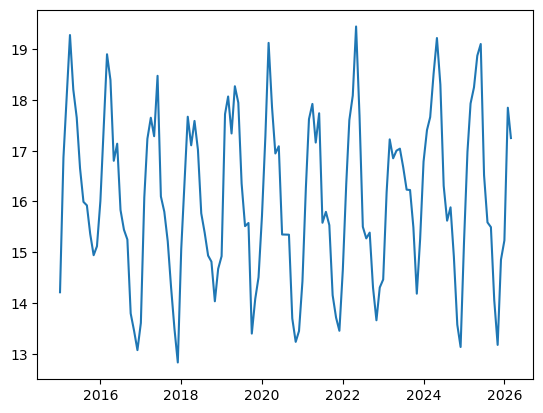

In [121]:
monthly_temp = data.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])

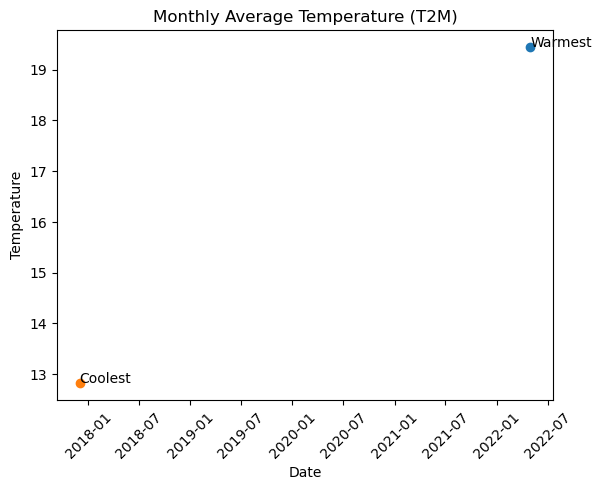

In [122]:
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.scatter(max_row["Date"], max_row["T2M"])
plt.scatter(min_row["Date"], min_row["T2M"])

plt.text(max_row["Date"], max_row["T2M"], "Warmest")
plt.text(min_row["Date"], min_row["T2M"], "Coolest")

plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

### Monthly Total Precipitation

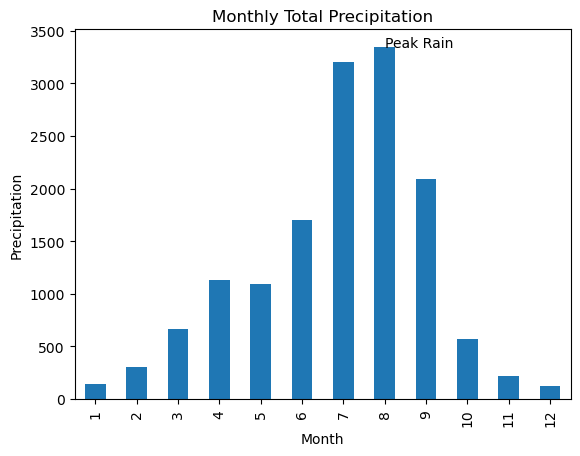

In [123]:
monthly_rain = data.groupby('Month')['PRECTOTCORR'].sum()

plt.figure()
monthly_rain.plot(kind="bar")

# Highlight peak
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.text(peak_month-1, peak_value, "Peak Rain")

plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Analysis

Temperature varies seasonally with clear warm and cool periods. The peak rainfall is recorded on August. As for 

the temperature, the coolest is recording in the first month of the year 2018 and the warmest on July of 2022.

### Correlation Heatmap

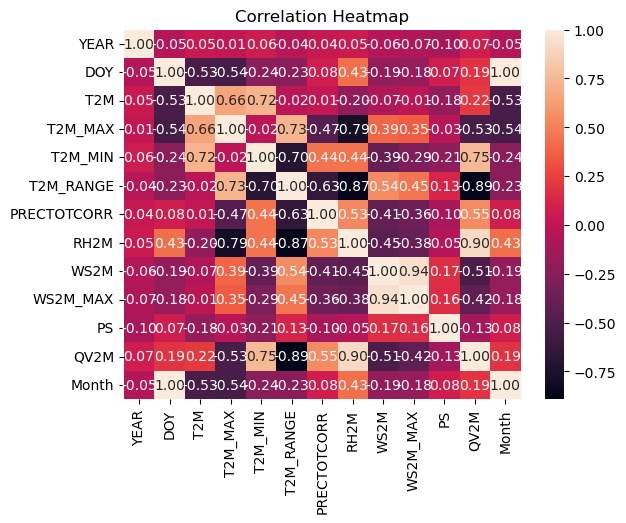

In [124]:
plt.figure()
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

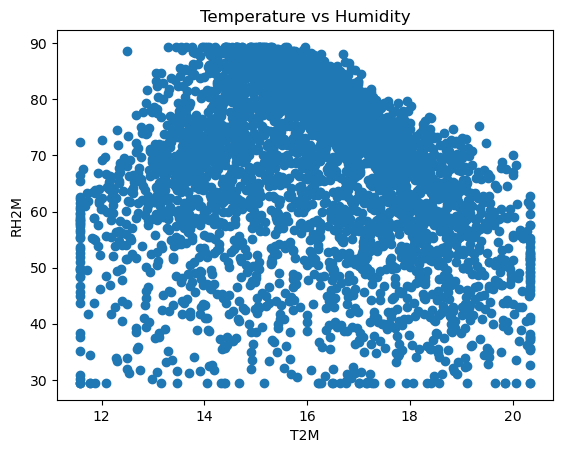

In [125]:
plt.figure()
plt.scatter(data["T2M"], data["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity")
plt.show()

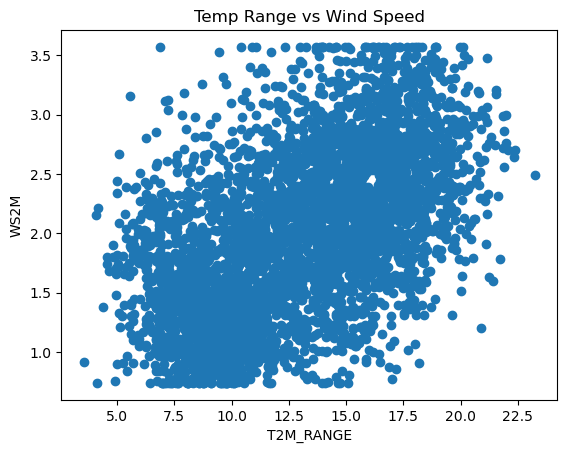

In [126]:
plt.figure()
plt.scatter(data["T2M_RANGE"], data["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [127]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  

print(corr_pairs.head(7))

Month     DOY         0.996557
DOY       Month       0.996557
WS2M_MAX  WS2M        0.941422
WS2M      WS2M_MAX    0.941422
QV2M      RH2M        0.904423
RH2M      QV2M        0.904423
QV2M      T2M_MIN     0.753301
dtype: float64


The strongest correlations in the dataset reveal both redundancy and physical relationships. Month and DOY are 
almost perfectly correlated (~0.997), indicating they encode the same temporal structure. WS2M and WS2M_MAX (~0.94) show stable wind behavior, where average and peak wind speeds move closely together. QV2M and RH2M (~0.90) reflect strong atmospheric moisture consistency across different humidity measures. Additionally, QV2M and T2M_MIN (~0.75) suggest warmer minimum temperatures are associated with higher moisture levels.

### Distribution Analysis


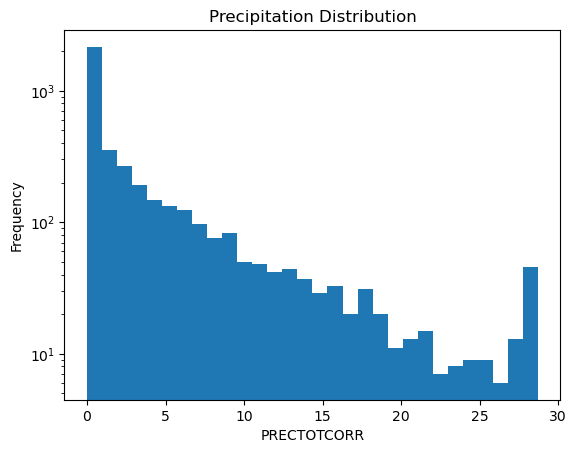

In [128]:
plt.figure()
plt.hist(data["PRECTOTCORR"], bins=30)

plt.yscale("log")  # helps if skewed

plt.title("Precipitation Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

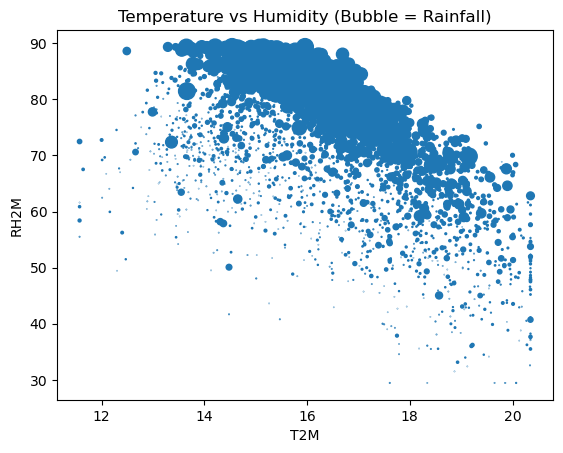

In [129]:
plt.figure()
plt.scatter(
    data["T2M"],
    data["RH2M"],
    s=data["PRECTOTCORR"] * 5  
)

plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()